<a href="https://colab.research.google.com/github/kartik0920/Hands-on-Machine-learning/blob/Main/chapter_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Loading the dataset

In [4]:
import pandas as pd
import numpy as np
import os


HOME_PATH="/content/drive/MyDrive/Jan 2k25/chapter 2"
DATA_URL=os.path.join(HOME_PATH,"housing.csv")

def loading_data(data_url=DATA_URL):
  return pd.read_csv(data_url)

In [10]:
data=loading_data()
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


##Data exploration

In [11]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [12]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
data["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [16]:
import matplotlib.pyplot as plt



array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

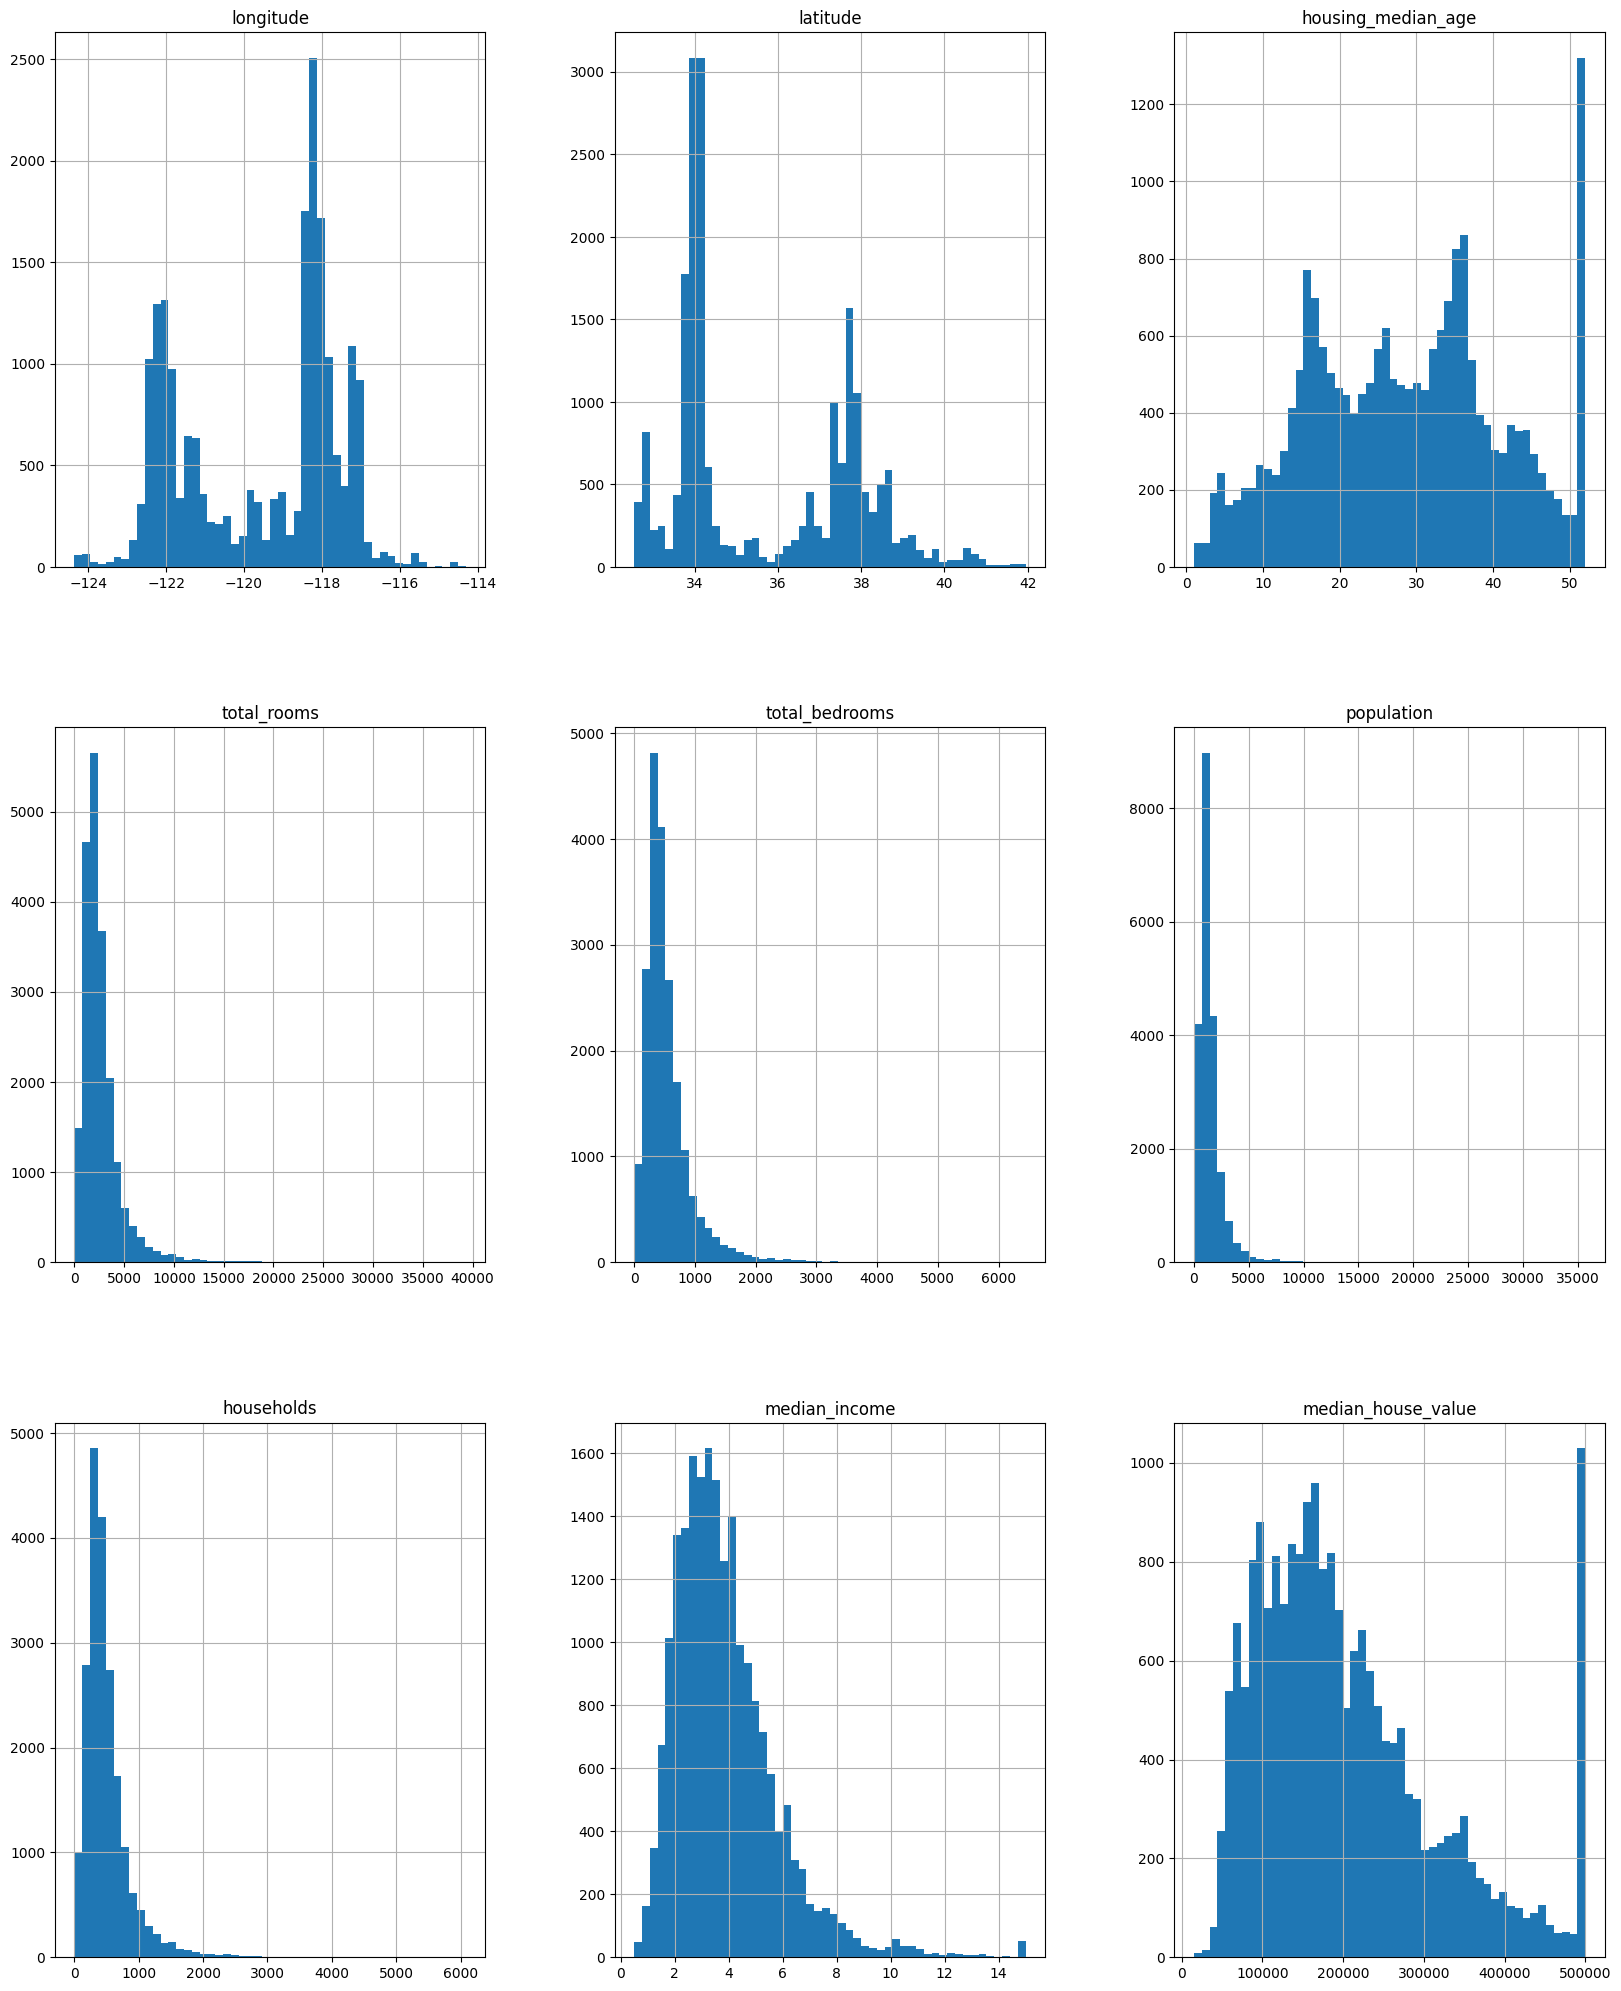

In [17]:
data.hist(bins=50,figsize=(20,25))

##Splitting of Data

we can use startified split for distributing data equally so no bias will get generated


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x=data.drop("median_house_value",axis=1)
y=data["median_house_value"]

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
train_set,test_set=train_test_split(data,test_size=0.1,random_state=42)

In [21]:
#x_train is housing and y_train is housing label

##Geographical Data Visualization

In [22]:
demo=train_set.copy()
demo.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5564,-118.29,33.91,41.0,2475.0,532.0,1416.0,470.0,3.8372,156400.0,<1H OCEAN
16016,-122.46,37.73,52.0,3547.0,506.0,1276.0,491.0,8.0069,426800.0,NEAR BAY
17131,-122.15,37.46,30.0,4198.0,1244.0,2678.0,1147.0,3.6712,308600.0,NEAR BAY
11752,-121.21,38.76,16.0,1608.0,296.0,792.0,286.0,3.1583,239200.0,INLAND
2308,-119.75,36.83,15.0,2793.0,436.0,1411.0,441.0,4.9292,109400.0,INLAND


<Axes: xlabel='latitude', ylabel='longitude'>

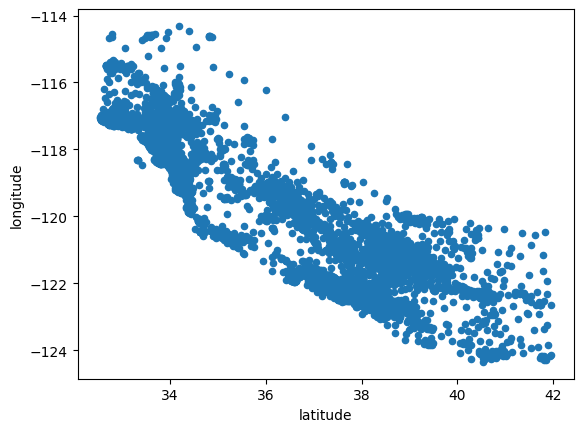

In [23]:
demo.plot(kind="scatter",x="latitude",y="longitude")

<Axes: xlabel='latitude', ylabel='longitude'>

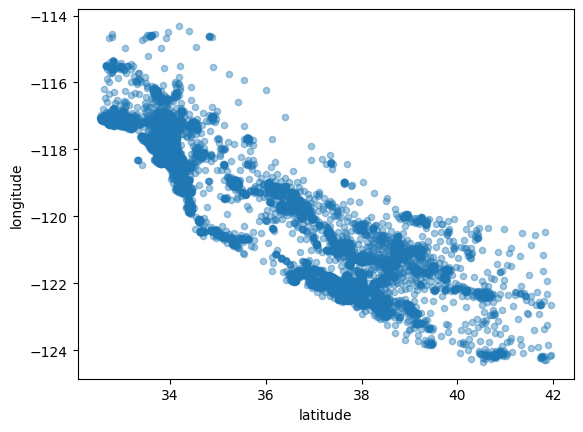

In [24]:
demo.plot(kind="scatter",x="latitude",y="longitude", alpha=0.4)

Alpha shows the transperency of element<br>
s is used to get size <br>
label is used to provide label/legend in plot<br>
c is used for color<br>
cmap is used for colormapping <br>
colorbar true is used for showing side menu for colors<br>

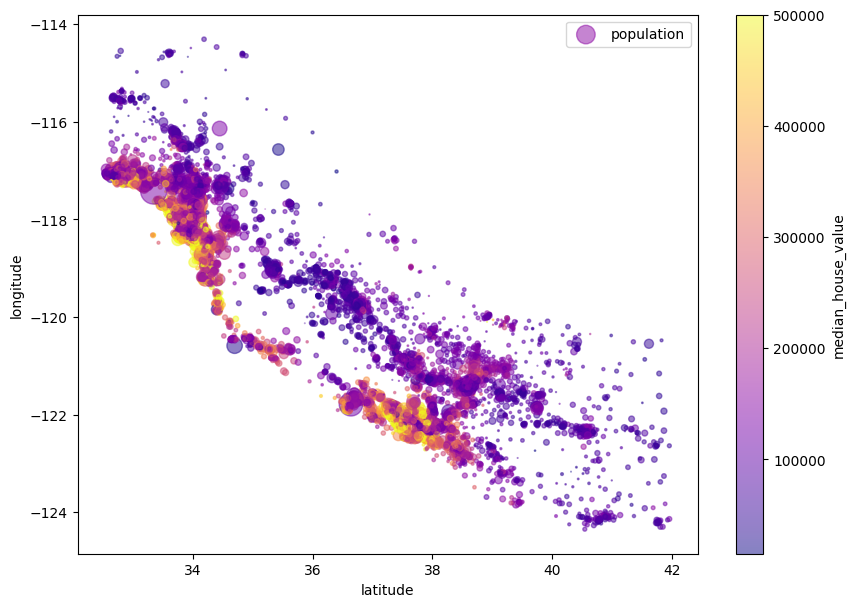

In [25]:
demo.plot(kind="scatter",x="latitude",y="longitude",alpha=0.5,
          s=demo["population"]/100,label="population", c="median_house_value",cmap=plt.get_cmap("plasma"),colorbar=True,
          figsize=(10,7)
          )

plt.show()

##Corelations

In [26]:
demo=demo.drop("ocean_proximity",axis=1)

In [27]:
corr_matrix=demo.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.689782
total_rooms,0.135327
housing_median_age,0.105493
households,0.065760
total_bedrooms,0.050577
population,-0.023859
longitude,-0.047552
latitude,-0.142503


In [28]:
demo["rooms_per_household"] = demo["total_rooms"]/demo["households"]
demo["bedrooms_per_room"] = demo["total_bedrooms"]/demo["total_rooms"]
demo["population_per_household"]=demo["population"]/demo["households"]

In [29]:
corr_matrix=demo.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.689782
rooms_per_household,0.148733
total_rooms,0.135327
housing_median_age,0.105493
households,0.065760
total_bedrooms,0.050577
population_per_household,-0.022905
population,-0.023859
longitude,-0.047552


##Data Cleaning


###handling null values

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [31]:
sample=data.copy()
sample=sample.dropna(subset=["total_bedrooms"])
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [32]:
sample=data.copy()
sample=sample.drop("total_bedrooms",axis=1)
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB


In [33]:
median=x_train["total_bedrooms"].median()
x_train["total_bedrooms"].fillna(median,inplace=True)
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


<ipython-input-33-92771b3bddff>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train["total_bedrooms"].fillna(median,inplace=True)


###handling text values

In [34]:
sample=x_train[["ocean_proximity"]]
sample.head(10)

,ocean_proximity
14196,NEAR OCEAN
8267,NEAR OCEAN
17445,NEAR OCEAN
14265,NEAR OCEAN
2271,INLAND
17848,<1H OCEAN
6252,<1H OCEAN
9389,NEAR BAY
6113,<1H OCEAN
6061,<1H OCEAN


In [35]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder=OneHotEncoder()
coded_categories=one_hot_encoder.fit_transform(sample)
coded_categories


<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [36]:
coded_categories.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [37]:
one_hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [38]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
coded_categories=ordinal_encoder.fit_transform(sample)
coded_categories


array([[4.],
       [4.],
       [4.],
       ...,
       [0.],
       [0.],
       [3.]])

In [39]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

###Creating Pipeline

In [40]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(data.values)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

demo=x_train.copy()
demo=demo.drop("ocean_proximity",axis=1)
num_pipeline = Pipeline([
     ('imputer', SimpleImputer(strategy="median")),
      ('attribs_adder', CombinedAttributesAdder()),
       ('std_scaler', StandardScaler()),
])
pipe_data = num_pipeline.fit_transform(demo)


In [42]:
from sklearn.compose import ColumnTransformer

num_attribs = list(demo)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

housing_prepared = full_pipeline.fit_transform(data)

In [43]:
housing_prepared

array([[-1.32783522,  1.05254828,  0.98214266, ...,  0.        ,
         1.        ,  0.        ],
       [-1.32284391,  1.04318455, -0.60701891, ...,  0.        ,
         1.        ,  0.        ],
       [-1.33282653,  1.03850269,  1.85618152, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.8237132 ,  1.77823747, -0.92485123, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87362627,  1.77823747, -0.84539315, ...,  0.        ,
         0.        ,  0.        ],
       [-0.83369581,  1.75014627, -1.00430931, ...,  0.        ,
         0.        ,  0.        ]])

In [44]:
x_train=full_pipeline.fit_transform(x_train)

##Training model


###Linear Regression


In [45]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg

LinearRegression()

In [46]:
lin_reg.fit(x_train,y_train)

LinearRegression()

In [47]:
x_test_transformed=full_pipeline.fit_transform(x_test)

In [48]:
from sklearn.metrics import   mean_squared_error
prediction=lin_reg.predict(x_test_transformed)
lin_mse=mean_squared_error(y_test,prediction)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

71067.06604346124

###Decision Tree
Beacuse of underfiitng of the data




In [49]:
from sklearn.tree import DecisionTreeRegressor
tree_reg=DecisionTreeRegressor()
tree_reg.fit(x_train,y_train)

DecisionTreeRegressor()

In [50]:
predictions_tree=tree_reg.predict(x_test_transformed)
predictions_tree

array([ 42500., 120100., 390800., ..., 500001., 122300., 145200.])

In [51]:
tree_mse=mean_squared_error(y_test,predictions_tree)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

104570.82579161509

In [52]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(tree_reg,x_train,y_train,scoring="neg_mean_squared_error",cv=10)

In [53]:
tree_rmse_scores=np.sqrt(-scores)

In [54]:
def showScores(scores):
  print(f'Scores={scores}')
  print(f'mean :{scores.mean()}')
  print(f'std dev:{scores.std()}')

In [55]:
showScores(tree_rmse_scores)

Scores=[65900.10330164 70051.56209522 68668.9695158  71967.47546674
 71937.38544395 68337.97353637 67500.57118478 67277.73142556
 66798.516119   70476.80880147]
mean :68891.70968905259
std dev:2020.4422760128537


In [56]:
lin_reg_score=cross_val_score(lin_reg,x_train,y_train,scoring="neg_mean_squared_error",cv=10)

In [57]:
lin_reg_rmse=np.sqrt(-lin_reg_score)

In [58]:
showScores(lin_reg_rmse)

Scores=[65000.67382615 70960.56056304 67122.63935124 66089.63153865
 68402.54686442 65266.34735288 65218.78174481 68525.46981754
 72739.87555996 68957.34111906]
mean :67828.38677377408
std dev:2468.091395065225


###Random Forest


In [59]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [60]:
prediction_random_forest=rf_model.predict(x_test_transformed)
rf_mse=mean_squared_error(y_test,prediction_random_forest)
rf_rmse=np.sqrt(rf_mse)
rf_rmse

78485.05976751952

In [61]:
rf_scores=cross_val_score(rf_model,x_train,y_train,cv=10,scoring="neg_mean_squared_error")

In [62]:
rf_rmse=np.sqrt(-rf_scores)

In [63]:
showScores(rf_rmse)

Scores=[47150.09300974 51912.42544698 49529.33230233 52034.49640121
 52491.59255855 47132.98528229 47861.48057406 50890.54942805
 49514.5848629  50022.01358149]
mean :49853.95534476059
std dev:1896.2335605008461


###Exporting model

In [64]:
# import joblib

# joblib.dump(rf_model,"Random_forest.pkl")

In [65]:
# #if disconnected
# import joblib
# rf_model=joblib.load("Random_forest.pkl")

##Fine tuning of the model

###Grid Search

In [66]:
from sklearn.model_selection import GridSearchCV
param_grid = [ {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
              {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [67]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [68]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30)

In [69]:
cvres = grid_search.cv_results_

In [70]:
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
  print(np.sqrt(-mean_score), params)

63343.02855881987 {'max_features': 2, 'n_estimators': 3}
55213.549000496394 {'max_features': 2, 'n_estimators': 10}
52440.810858962686 {'max_features': 2, 'n_estimators': 30}
60224.40738326237 {'max_features': 4, 'n_estimators': 3}
52870.27650005614 {'max_features': 4, 'n_estimators': 10}
50337.542320176304 {'max_features': 4, 'n_estimators': 30}
57961.38743863914 {'max_features': 6, 'n_estimators': 3}
52078.973050143264 {'max_features': 6, 'n_estimators': 10}
49789.43847992339 {'max_features': 6, 'n_estimators': 30}
57808.103092984005 {'max_features': 8, 'n_estimators': 3}
52439.471226951086 {'max_features': 8, 'n_estimators': 10}
50280.43606531873 {'max_features': 8, 'n_estimators': 30}
61504.23920747334 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54239.08868003933 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60298.60618843991 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52225.196314475965 {'bootstrap': False, 'max_features': 3, 'n_estimato

###testing on test sets


In [71]:
final_model=grid_search.best_estimator_


In [72]:
final_predictions=final_model.predict(x_test_transformed)
final_mse=mean_squared_error(final_predictions,y_test)
final_mse

4573420030.535535

In [73]:
final_rmse=np.sqrt(final_mse)
final_rmse

67627.0658134414

#Ensemble Learning

In [75]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import cross_val_score
vt_reg=VotingRegressor(
    estimators=[('lr',lin_reg),('rf',rf_model)],
)



In [80]:
vt_reg_rmse=cross_val_score(vt_reg,x_train,y_train,cv=3,scoring="neg_median_absolute_error").mean()

In [81]:
np.sqrt(-vt_reg_rmse)

166.38432089753806

In [82]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [84]:
bag_reg=BaggingRegressor(DecisionTreeRegressor(),n_estimators=500,max_samples=100,bootstrap=True,n_jobs=-1,oob_score=True)

In [85]:
bag_reg_rmse=cross_val_score(bag_reg,x_train,y_train,cv=3,scoring="neg_median_absolute_error").mean()

In [86]:
np.sqrt(-bag_reg_rmse)

183.8138705321228

Random Forest

In [92]:
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators=500,max_leaf_nodes=16,n_jobs=-1,max_depth=5)

In [93]:
rf_reg_rmse=cross_val_score(rf_reg,x_train,y_train,cv=3,scoring="neg_median_absolute_error").mean()

In [94]:
np.sqrt(-rf_reg_rmse)

187.4496717986245

boosting

In [95]:
from sklearn.ensemble import AdaBoostRegressor
ada_reg=AdaBoostRegressor(DecisionTreeRegressor(max_depth=4),n_estimators=200,learning_rate=0.5)

In [96]:
ada_reg_rmse=cross_val_score(ada_reg,x_train,y_train,cv=3,scoring="neg_median_absolute_error").mean()

In [97]:
np.sqrt(-ada_reg_rmse)

256.27035035709906